In [185]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules,fpgrowth
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
dataset = [
    ['Milk', 'Bread', 'Butter'], ['Bread', 'Eggs', 'Butter', 'Jam'], ['Milk', 'Bread', 'Eggs'],
    ['Milk', 'Bread', 'Butter', 'Eggs'], ['Bread', 'Butter'], ['Milk', 'Butter', 'Jam'],
    ['Bread', 'Eggs'], ['Milk', 'Bread', 'Butter'], ['Bread', 'Butter', 'Eggs'], ['Milk', 'Eggs'],
    ['Milk', 'Bread', 'Butter'], ['Bread', 'Eggs', 'Butter', 'Jam'], ['Milk', 'Bread', 'Eggs'],
    ['Milk', 'Bread', 'Butter', 'Eggs'], ['Bread', 'Butter'], ['Milk', 'Bread', 'Butter'],
    ['Bread', 'Eggs', 'Butter'], ['Milk', 'Bread', 'Eggs'], ['Milk', 'Bread', 'Butter', 'Eggs'], ['Bread', 'Butter'],
    ['Milk', 'Bread', 'Butter'], ['Bread', 'Eggs', 'Butter', 'Jam'], ['Milk', 'Bread', 'Eggs'],
    ['Milk', 'Bread', 'Butter', 'Eggs'], ['Bread', 'Butter'], ['Milk', 'Butter'],
    ['Bread', 'Eggs'], ['Milk', 'Bread', 'Butter'], ['Bread', 'Butter', 'Eggs'], ['Milk', 'Eggs'],
    ['Milk', 'Bread', 'Butter'], ['Bread', 'Eggs', 'Butter', 'Jam'], ['Milk', 'Bread', 'Eggs'],
    ['Milk', 'Bread', 'Butter', 'Eggs'], ['Bread', 'Butter'], ['Milk', 'Bread', 'Butter'],
    ['Bread', 'Eggs', 'Butter'], ['Milk', 'Bread', 'Eggs'], ['Milk', 'Bread', 'Butter', 'Eggs'], ['Bread', 'Butter'],
    ['Milk', 'Bread', 'Butter'], ['Bread', 'Eggs', 'Butter', 'Jam'], ['Milk', 'Bread', 'Eggs'],
    ['Milk', 'Bread', 'Butter', 'Eggs'], ['Bread', 'Butter'], ['Milk', 'Butter'],
    ['Bread', 'Eggs'], ['Milk', 'Bread', 'Butter'], ['Bread', 'Butter', 'Eggs'], ['Milk', 'Eggs'],
    ['Milk', 'Bread', 'Butter'], ['Bread', 'Eggs', 'Butter', 'Jam'], ['Milk', 'Bread', 'Eggs'],
    ['Milk', 'Bread', 'Butter', 'Eggs'], ['Bread', 'Butter'], ['Milk', 'Bread', 'Butter'],
    ['Bread', 'Eggs', 'Butter'], ['Milk', 'Bread', 'Eggs'], ['Milk', 'Bread', 'Butter', 'Eggs'], ['Bread', 'Butter'],
    ['Milk', 'Bread', 'Butter'], ['Bread', 'Eggs', 'Butter', 'Jam'], ['Milk', 'Bread', 'Eggs'],
    ['Milk', 'Bread', 'Butter', 'Eggs'], ['Bread', 'Butter'], ['Milk', 'Butter'],
    ['Bread', 'Eggs'], ['Milk', 'Bread', 'Butter'], ['Bread', 'Butter', 'Eggs'], ['Milk', 'Eggs'],
    ['Milk', 'Bread', 'Butter'], ['Bread', 'Eggs', 'Butter', 'Jam'], ['Milk', 'Bread', 'Eggs'],
    ['Milk', 'Bread', 'Butter', 'Eggs'], ['Bread', 'Butter'], ['Milk', 'Bread', 'Butter'],
    ['Bread', 'Eggs', 'Butter'], ['Milk', 'Bread', 'Eggs'], ['Milk', 'Bread', 'Butter', 'Eggs'], ['Bread', 'Butter'],
    ['Milk', 'Bread', 'Butter'], ['Bread', 'Eggs', 'Butter', 'Jam'], ['Milk', 'Bread', 'Eggs'],
    ['Milk', 'Bread', 'Butter', 'Eggs'], ['Bread', 'Butter'], ['Milk', 'Butter'],
    ['Bread', 'Eggs'], ['Milk', 'Bread', 'Butter'], ['Bread', 'Butter', 'Eggs'], ['Milk', 'Eggs'],
    ['Milk', 'Bread', 'Butter'], ['Bread', 'Eggs', 'Butter', 'Jam'], ['Milk', 'Bread', 'Eggs'],
    ['Milk', 'Bread', 'Butter', 'Eggs'], ['Bread', 'Butter'], ['Milk', 'Bread', 'Butter'],
    ['Bread', 'Eggs', 'Butter'], ['Milk', 'Bread', 'Eggs'], ['Milk', 'Bread', 'Butter', 'Eggs'], ['Bread', 'Butter']
]


te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset)
df = pd.DataFrame(te_ary, columns=te.columns_)

print(df.head())

   Bread  Butter   Eggs    Jam   Milk
0   True    True  False  False   True
1   True    True   True   True  False
2   True   False   True  False   True
3   True    True   True  False   True
4   True    True  False  False  False


In [187]:
# Find frequent itemsets with minimum support = 0.3
frequent_itemsets = apriori(df, min_support=0.3, use_colnames=True)
print(frequent_itemsets.sort_values(by='support', ascending=False).to_string(index=False))
print(len(frequent_itemsets))

 support                         itemsets
    0.90               frozenset({Bread})
    0.75              frozenset({Butter})
    0.70       frozenset({Bread, Butter})
    0.60                frozenset({Eggs})
    0.60                frozenset({Milk})
    0.55         frozenset({Bread, Eggs})
    0.50         frozenset({Bread, Milk})
    0.40        frozenset({Butter, Milk})
    0.35        frozenset({Butter, Eggs})
    0.35          frozenset({Eggs, Milk})
    0.35 frozenset({Bread, Butter, Eggs})
    0.35 frozenset({Bread, Butter, Milk})
    0.30   frozenset({Bread, Eggs, Milk})
13


In [188]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)
print(rules[['antecedents','consequents','support','confidence','lift']])
print(f"Rules generated by Apriori: {len(rules)}")

                  antecedents          consequents  support  confidence  \
0          frozenset({Bread})  frozenset({Butter})     0.70    0.777778   
1         frozenset({Butter})   frozenset({Bread})     0.70    0.933333   
2          frozenset({Bread})    frozenset({Eggs})     0.55    0.611111   
3           frozenset({Eggs})   frozenset({Bread})     0.55    0.916667   
4           frozenset({Milk})   frozenset({Bread})     0.50    0.833333   
5           frozenset({Milk})  frozenset({Butter})     0.40    0.666667   
6    frozenset({Bread, Eggs})  frozenset({Butter})     0.35    0.636364   
7   frozenset({Butter, Eggs})   frozenset({Bread})     0.35    1.000000   
8    frozenset({Bread, Milk})  frozenset({Butter})     0.35    0.700000   
9   frozenset({Butter, Milk})   frozenset({Bread})     0.35    0.875000   
10   frozenset({Bread, Milk})    frozenset({Eggs})     0.30    0.600000   
11    frozenset({Eggs, Milk})   frozenset({Bread})     0.30    0.857143   

        lift  
0   1.037

In [189]:
frequent_fp = fpgrowth(df, min_support=0.3, use_colnames=True)
rules_fp = association_rules(frequent_fp, metric="lift",min_threshold=1.0)
print(rules_fp[['antecedents','consequents','support','confidence','lift']])
print(f"Rules generated by FP-Growth: {len(rules_fp)}")

                 antecedents                consequents  support  confidence  \
0         frozenset({Bread})        frozenset({Butter})     0.70    0.777778   
1        frozenset({Butter})         frozenset({Bread})     0.70    0.933333   
2   frozenset({Bread, Milk})          frozenset({Eggs})     0.30    0.600000   
3          frozenset({Eggs})   frozenset({Bread, Milk})     0.30    0.500000   
4         frozenset({Bread})          frozenset({Eggs})     0.55    0.611111   
5          frozenset({Eggs})         frozenset({Bread})     0.55    0.916667   
6  frozenset({Butter, Eggs})         frozenset({Bread})     0.35    1.000000   
7         frozenset({Bread})  frozenset({Butter, Eggs})     0.35    0.388889   

       lift  
0  1.037037  
1  1.037037  
2  1.000000  
3  1.000000  
4  1.018519  
5  1.018519  
6  1.111111  
7  1.111111  
Rules generated by FP-Growth: 8


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20376\3755510363.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='support', y='itemsets', data=top_10_itemsets, palette='viridis')


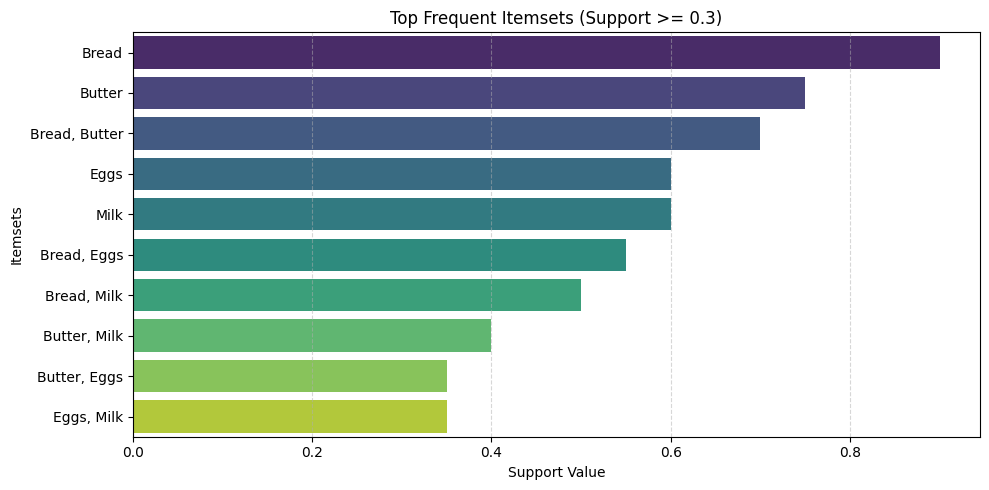

In [190]:
# Sort and pick the top itemsets
top_10_itemsets = frequent_itemsets.sort_values(by='support', ascending=False).head(10).copy()

# Convert itemsets frozenset type to string strings for clean plotting labels
top_10_itemsets['itemsets'] = top_10_itemsets['itemsets'].apply(lambda x: ', '.join(list(x)))

# Plotting
plt.figure(figsize=(10, 5))
sns.barplot(x='support', y='itemsets', data=top_10_itemsets, palette='viridis')
plt.title('Top Frequent Itemsets (Support >= 0.3)')
plt.xlabel('Support Value')
plt.ylabel('Itemsets')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [191]:
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].to_string(index=False))


              antecedents         consequents  support  confidence     lift
       frozenset({Bread}) frozenset({Butter})     0.70    0.777778 1.037037
      frozenset({Butter})  frozenset({Bread})     0.70    0.933333 1.037037
       frozenset({Bread})   frozenset({Eggs})     0.55    0.611111 1.018519
        frozenset({Eggs})  frozenset({Bread})     0.55    0.916667 1.018519
        frozenset({Milk})  frozenset({Bread})     0.50    0.833333 0.925926
        frozenset({Milk}) frozenset({Butter})     0.40    0.666667 0.888889
 frozenset({Bread, Eggs}) frozenset({Butter})     0.35    0.636364 0.848485
frozenset({Butter, Eggs})  frozenset({Bread})     0.35    1.000000 1.111111
 frozenset({Bread, Milk}) frozenset({Butter})     0.35    0.700000 0.933333
frozenset({Butter, Milk})  frozenset({Bread})     0.35    0.875000 0.972222
 frozenset({Bread, Milk})   frozenset({Eggs})     0.30    0.600000 1.000000
  frozenset({Eggs, Milk})  frozenset({Bread})     0.30    0.857143 0.952381
